<a href="https://colab.research.google.com/github/VInitha24057/amazon-sales-/blob/main/Amazon_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/Amazon Sales data.csv')



In [ ]:
# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check for null values
df.isnull().sum()


,0
Region,0
Country,0
Item Type,0
Sales Channel,0
Order Priority,0
Order Date,0
Order ID,0
Ship Date,0
Units Sold,0
Unit Price,0


In [ ]:
# Add shipping time
df['Shipping Time (days)'] = (df['Ship Date'] - df['Order Date']).dt.days

# Check data types and descriptive statistics
df.describe(include='all')


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Shipping Duration,Year-Month,Shipping Time (days)
count,99,99,99,99,99,99,9.900000e+01,99,99.000000,99.000000,99.000000,9.900000e+01,9.900000e+01,9.900000e+01,99.000000,99,99.000000
unique,7,75,12,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60,NaN
top,Sub-Saharan Africa,The Gambia,Clothes,Online,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-11,NaN
freq,36,4,13,50,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
mean,NaN,NaN,NaN,NaN,NaN,2013-09-17 08:00:00,5.582919e+08,2013-10-10 12:07:16.363636480,5080.595960,275.140707,190.317879,1.343677e+06,9.149062e+05,4.287705e+05,23.171717,NaN,23.171717
min,NaN,NaN,NaN,NaN,NaN,2010-02-02 00:00:00,1.146066e+08,2010-02-25 00:00:00,124.000000,9.330000,6.920000,4.870260e+03,3.612240e+03,1.258020e+03,0.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,2012-02-13 00:00:00,3.435679e+08,2012-02-21 12:00:00,2825.500000,81.730000,35.840000,2.650320e+05,1.668760e+05,1.208574e+05,9.500000,NaN,9.500000
50%,NaN,NaN,NaN,NaN,NaN,2013-07-20 00:00:00,5.594271e+08,2013-08-07 00:00:00,5367.000000,154.060000,97.440000,7.454260e+05,3.631980e+05,2.850876e+05,23.000000,NaN,23.000000
75%,NaN,NaN,NaN,NaN,NaN,2015-04-13 00:00:00,7.923336e+08,2015-05-08 00:00:00,7334.500000,437.200000,263.330000,2.105066e+06,1.558613e+06,6.336292e+05,35.500000,NaN,35.500000
max,NaN,NaN,NaN,NaN,NaN,2017-05-22 00:00:00,9.940222e+08,2017-06-17 00:00:00,9925.000000,668.270000,524.960000,5.997055e+06,4.509794e+06,1.678541e+06,50.000000,NaN,50.000000


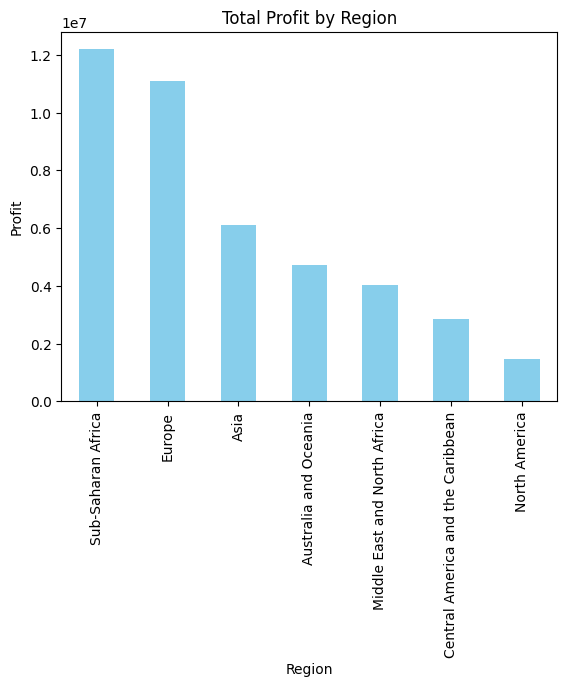

In [ ]:
import matplotlib.pyplot as plt

region_profit = df.groupby('Region')['Total Profit'].sum().sort_values(ascending=False)
region_profit.plot(kind='bar', color='skyblue', title="Total Profit by Region")
plt.ylabel("Profit")
plt.show()


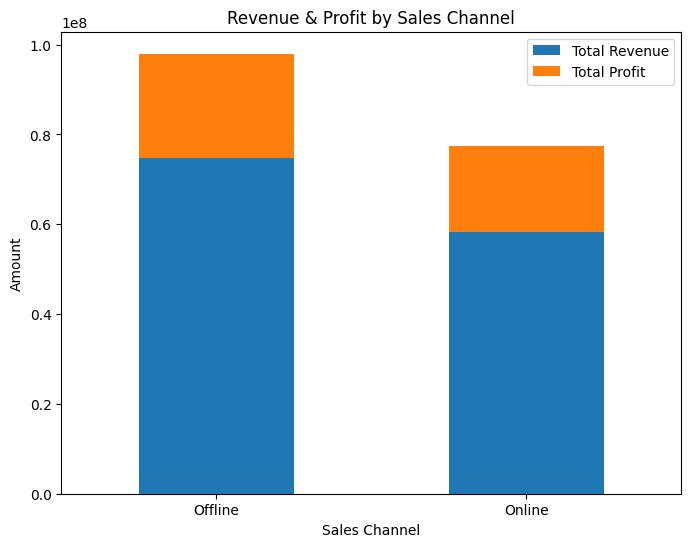

In [ ]:
channel = df.groupby('Sales Channel')[['Total Revenue', 'Total Profit']].sum()
channel.plot(kind='bar', stacked=True, figsize=(8,6), title="Revenue & Profit by Sales Channel")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()


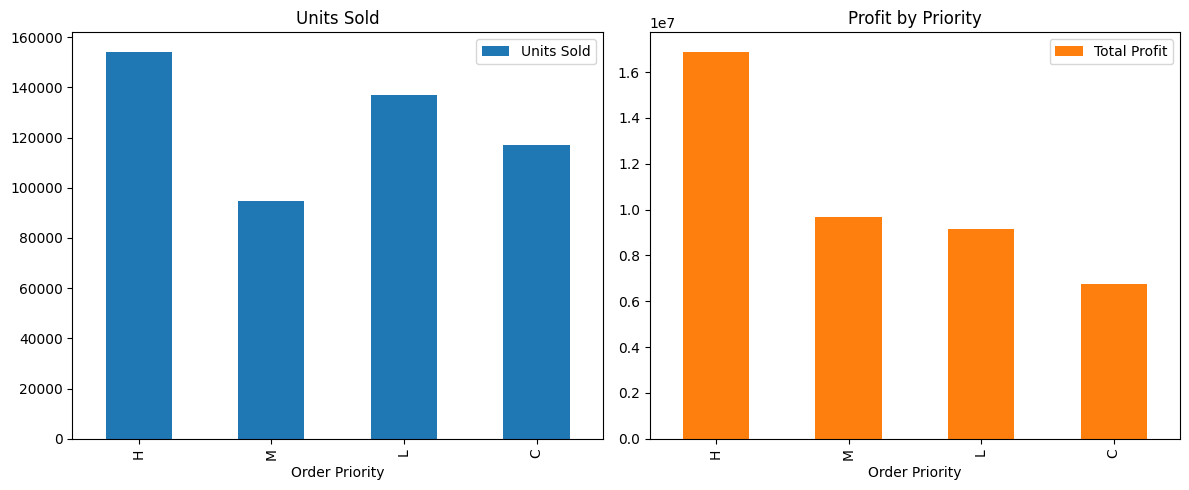

In [ ]:
priority = df.groupby('Order Priority')[['Units Sold', 'Total Profit']].sum().sort_values(by='Total Profit', ascending=False)
priority.plot(kind='bar', subplots=True, layout=(1,2), figsize=(12,5), sharex=True, title=["Units Sold", "Profit by Priority"])
plt.tight_layout()
plt.show()


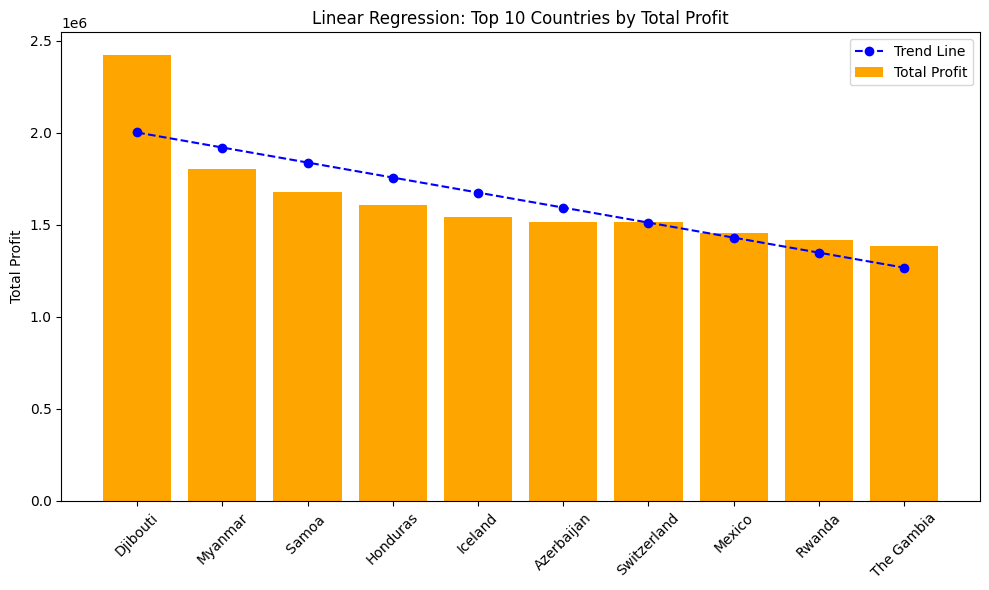

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

top_countries = df.groupby('Country')['Total Profit'].sum().sort_values(ascending=False).head(10)

# Encode countries
X = np.arange(len(top_countries)).reshape(-1,1)
y = top_countries.values.reshape(-1,1)

# Fit regression
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

# Plot
plt.figure(figsize=(10,6))
plt.bar(top_countries.index, y.flatten(), color='orange', label='Total Profit')
plt.plot(top_countries.index, y_pred.flatten(), color='blue', linestyle='--', marker='o', label='Trend Line')
plt.title("Linear Regression: Top 10 Countries by Total Profit")
plt.xticks(rotation=45)
plt.ylabel("Total Profit")
plt.legend()
plt.tight_layout()
plt.show()



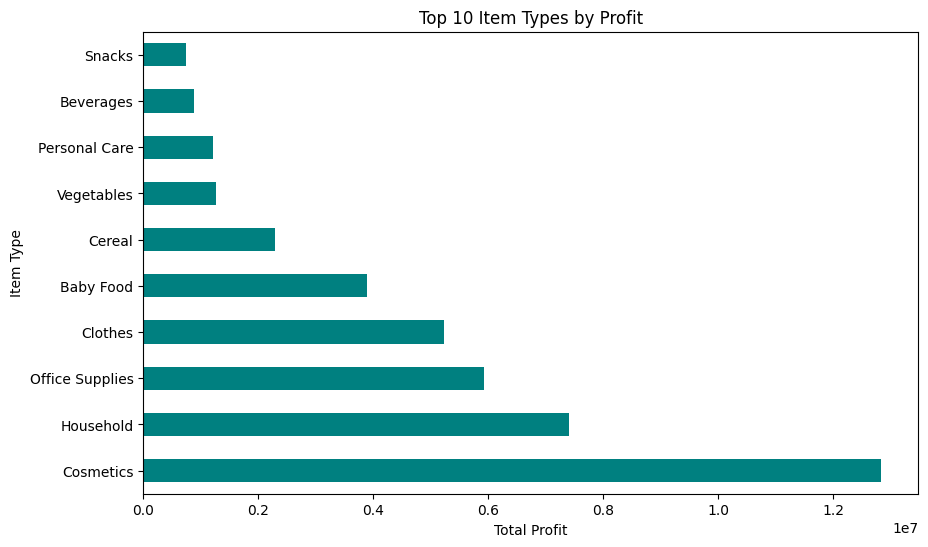

In [ ]:
item_profit = df.groupby('Item Type')['Total Profit'].sum().sort_values(ascending=False).head(10)
item_profit.plot(kind='barh', color='teal', title='Top 10 Item Types by Profit', figsize=(10,6))
plt.xlabel("Total Profit")
plt.show()
